#Final Project Instructions

Few ideas: Regression, Classification, Clustering, PCA
Guidelines:
1. ML framework to be used: Scikit-Learn
2. Visualisation library: matplotlib or seaborn
3. All cells fully executed without error
4. Notebook contents to follow:
- Introduction: The introduction section must include the background of case selection, the data used (amount of data, classes, sources in the form of links), and the objectives to be achieved.
- Import Required Libraries: The first cell in the notebook must contain and only contain all the libraries used in the project.
- Data Loading & Exploratory Data Analysis: This section contains the data loading process, which is then followed by exploratory data analysis (EDA). The EDA process must involve the use of visualization libraries. For example, EDA may include visualizing class distribution in the data, image size distribution (for CV topics), or sentence length distribution (for NLP topics), as well as other necessary data exploration.
- Data Preprocessing: This section contains the process of preparing data for model training, such as splitting the data into train-dev-test, data transformation (normalization, encoding, etc.), and other required processes.
- Model Definition: This section contains the cells for defining the model up to model compilation. It is better if preceded by an explanation of why a certain architecture or model type was chosen, the reasons for selecting specific hyperparameter values, and other related matters.
- Model Training: The cell in this section must only contain code to train the model and the output produced.
- Model Evaluation: In this section, model evaluation must be carried out to show how the model performs based on the chosen metrics. This must be demonstrated with visualizations of performance trends and/or model error rates.
- Model Inference: This section contains model inference, where the trained model will be tested on data other than the available dataset. The data used can be synthetic data created by students or data obtained from the internet.
- Conclusion: In this final chapter, it must contain conclusions that reflect the results obtained compared to the objectives stated in the introduction.

#Machine Learning Project Assessment Rubric:

1	Data Wrangling	Able to perform data loading, initial exploration, and data cleaning using Pandas efficiently and correctly.
2	Exploratory Data Analysis (EDA)	Create at least 5 visualization graphs for data exploration and provide clear insights from these visualizations.
3	Feature Engineering	Perform processes such as feature selection, splitting into train-test, transformation of numerical/categorical data, and appropriate encoding.
4	Modeling	Build at least 2 types of models (e.g., decision tree, logistic regression, etc.), and train the models with appropriate data.
5	Model Evaluation	Determine evaluation metrics that are appropriate for the model type, and calculate those metrics (accuracy, RMSE, F1, etc.).
6	Model Analysis	Provide interpretation of the modeling and evaluation results comprehensively.
7	Code Runs Without Error	All code runs without errors, and main functionalities work correctly.
8	Readability	The notebook is well-documented, using Markdown and comments in the code to explain the analysis flow.
9	Final Conclusion	Provide a summary of the final results of the entire machine learning pipeline in a logical and easy-to-understand manner.

In [3]:
pip install kmodes

Note: you may need to restart the kernel to use updated packages.


In [64]:
# Import all required libraries

# Core
import os, math, json, joblib
from pathlib import Path
from typing import List, Dict

# Data handling & visualization
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

# Statistics & utilities
from scipy import stats

# Scikit-learn: datasets, preprocessing, model selection, pipelines
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
)
from sklearn.pipeline import Pipeline

# Scikit-learn: models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, StackingClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression

# Scikit-learn: metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, silhouette_score
)

# Scikit-learn: dimensionality reduction & clustering
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN

# K-modes / K-prototypes (for categorical clustering)
from kmodes.kmodes import KModes
from kmodes.kprototypes import KPrototypes

In [65]:
# import data

df_lottery = pd.read_csv("dataset/Tattslotto.csv")
df_lottery.head()

,Draw,Date,1,2,3,4,5,6
0,4601,23/08/2025,2,10,28,33,44,45
1,4599,16/08/2025,1,6,15,18,23,38
2,4597,9/08/2025,4,10,14,40,41,45
3,4595,2/08/2025,1,21,24,40,43,45
4,4593,26/07/2025,2,17,23,40,42,44


In [66]:
#drop "Draw" number column - this is unique column that can be represented by draw date already. Draw number will no be required so it can be dropped
df_lottery = df_lottery.drop(columns=['Draw'])

In [67]:
#change column name so it is easy to differentiate header with contents
df_lottery = df_lottery.rename(columns={
    '1': 'ball_number_1',
    '2': 'ball_number_2',
    '3': 'ball_number_3',
    '4': 'ball_number_4',
    '5': 'ball_number_5',
    '6': 'ball_number_6'
})

In [68]:
#dataset without draw number and with new column header name
df_lottery.head()

,Date,ball_number_1,ball_number_2,ball_number_3,ball_number_4,ball_number_5,ball_number_6
0,23/08/2025,2,10,28,33,44,45
1,16/08/2025,1,6,15,18,23,38
2,9/08/2025,4,10,14,40,41,45
3,2/08/2025,1,21,24,40,43,45
4,26/07/2025,2,17,23,40,42,44


In [69]:
#check the data type
df_lottery.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 921 entries, 0 to 920
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           921 non-null    object
 1   ball_number_1  921 non-null    int64 
 2   ball_number_2  921 non-null    int64 
 3   ball_number_3  921 non-null    int64 
 4   ball_number_4  921 non-null    int64 
 5   ball_number_5  921 non-null    int64 
 6   ball_number_6  921 non-null    int64 
dtypes: int64(6), object(1)
memory usage: 50.5+ KB


The data is already clean - not required further cleaning

In [70]:
#quick inspection on the dataframe, 
print("Shape:", df_lottery.shape) #returns a tuple (rows, columns), i.e. how many records and how many columns are in the dataset.
print("Columns:", list(df_lottery.columns)) #returns the names of the columns. Wrapping it in list() makes it print as a Python list instead of an Index object.

Shape: (921, 7)
Columns: ['Date', 'ball_number_1', 'ball_number_2', 'ball_number_3', 'ball_number_4', 'ball_number_5', 'ball_number_6']


In [71]:
#summary statistics of dataframe’s numeric columns
df_lottery.describe()


,ball_number_1,ball_number_2,ball_number_3,ball_number_4,ball_number_5,ball_number_6
count,921.000000,921.000000,921.000000,921.000000,921.000000,921.000000
mean,6.466884,13.188925,19.768730,26.134636,32.757872,39.334419
std,5.257215,6.754155,7.289043,7.468579,6.973787,5.217758
min,1.000000,2.000000,4.000000,7.000000,9.000000,13.000000
25%,2.000000,8.000000,14.000000,21.000000,28.000000,37.000000
50%,5.000000,12.000000,19.000000,26.000000,34.000000,41.000000
75%,9.000000,18.000000,25.000000,32.000000,38.000000,43.000000
max,30.000000,35.000000,42.000000,43.000000,44.000000,45.000000


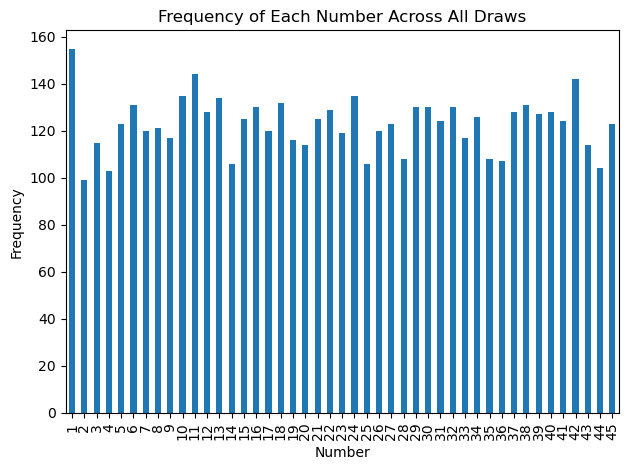

In [72]:
# 1) Frequency of each number across all draws
ball_cols = [col for col in df_lottery.columns if col.startswith("ball_number_")]

all_numbers = pd.Series(df_lottery[ball_cols].values.ravel(), name="number")
num_counts = all_numbers.value_counts().sort_index()

plt.figure()
num_counts.plot(kind="bar")
plt.title("Frequency of Each Number Across All Draws")
plt.xlabel("Number")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Insight:** Number frequencies are fairly uniform, as expected in random lottery draws, with minor variation at the edges.

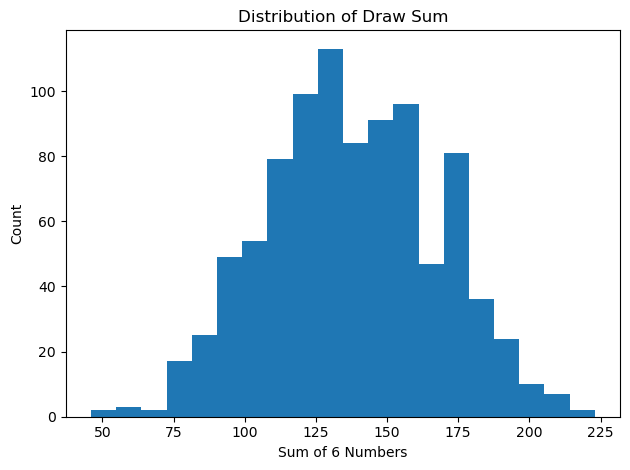

In [73]:
# 2) Distribution of the draw sum

ball_cols = [col for col in df_lottery.columns if col.startswith("ball_number_")]
df_lottery["sum_draw"] = df_lottery[ball_cols].sum(axis=1)

# Plot histogram of sum of balls
plt.figure()
plt.hist(df_lottery["sum_draw"], bins=20)
plt.title("Distribution of Draw Sum")
plt.xlabel("Sum of 6 Numbers")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

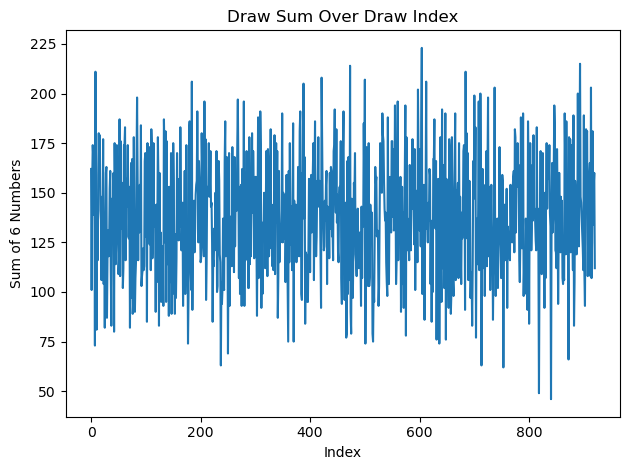

In [74]:
# 3) Draw sum over draw index

# Make sure sum_draw is calculated only from ball_number columns
ball_cols = [col for col in df_lottery.columns if col.startswith("ball_number_")]
df_lottery["sum_draw"] = df_lottery[ball_cols].sum(axis=1)

# Plot sum of draws over index
plt.figure()
plt.plot(df_lottery["sum_draw"].values)
plt.title("Draw Sum Over Draw Index")
plt.xlabel("Index")
plt.ylabel("Sum of 6 Numbers")
plt.tight_layout()
plt.show()

C:\Users\julya\AppData\Local\Temp\ipykernel_32988\1502669515.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_lottery[col] for col in ball_cols], labels=[f"{i}" for i in range(1, len(ball_cols)+1)])


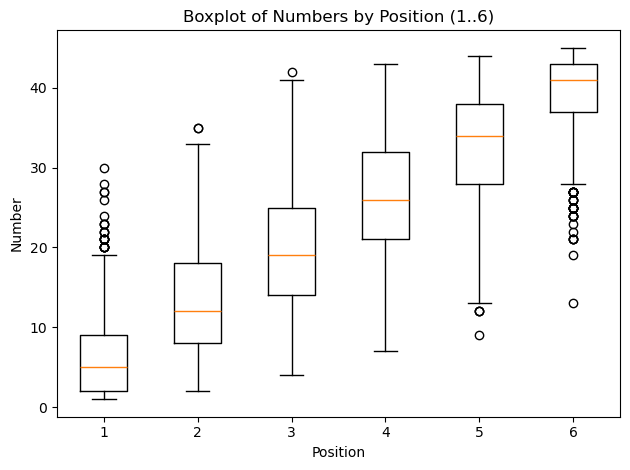

In [76]:
# 4) Boxplot by position
ball_cols = [col for col in df_lottery.columns if col.startswith("ball_number_")]

plt.figure()
plt.boxplot([df_lottery[col] for col in ball_cols], labels=[f"{i}" for i in range(1, len(ball_cols)+1)])
plt.title("Boxplot of Numbers by Position (1..6)")
plt.xlabel("Position")
plt.ylabel("Number")
plt.tight_layout()
plt.show()

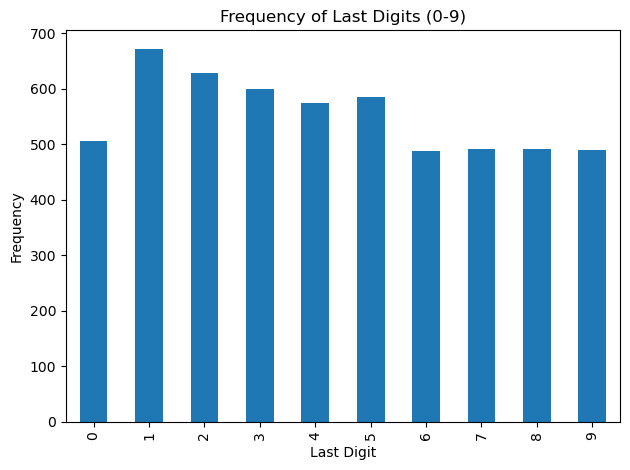

In [77]:
# 5) Frequency of last digits (0-9)

# Collect all ball columns
ball_cols = [col for col in df_lottery.columns if col.startswith("ball_number_")]

# Flatten all ball numbers into one Series
all_numbers = pd.Series(df_lottery[ball_cols].values.ravel(), name="number")

# Compute last digits
last_digits = all_numbers.astype(int) % 10
ld_counts = last_digits.value_counts().sort_index()

# Plot frequency of last digits
plt.figure()
ld_counts.plot(kind="bar")
plt.title("Frequency of Last Digits (0-9)")
plt.xlabel("Last Digit")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Using columns: ['ball_number_1', 'ball_number_2', 'ball_number_3', 'ball_number_4', 'ball_number_5', 'ball_number_6']
Total numbers collected: 5526


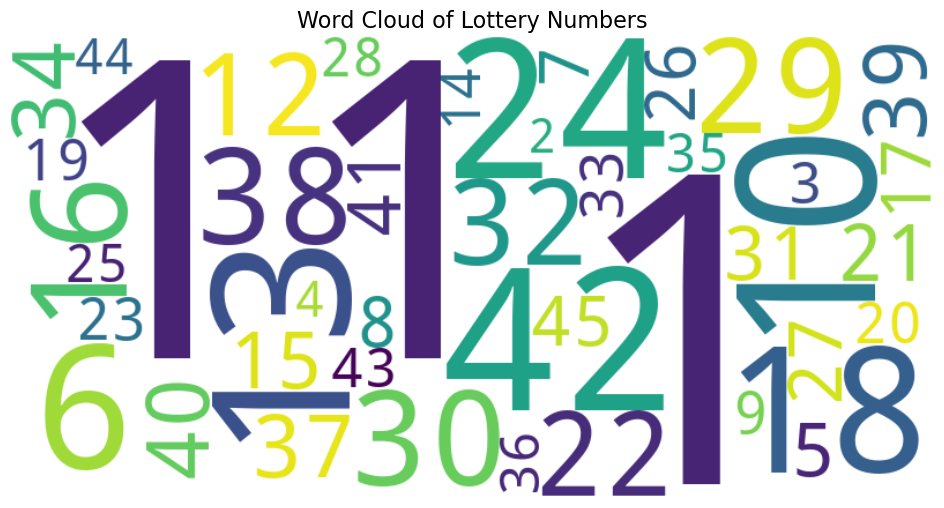

In [92]:
# === Word Cloud of Lottery Numbers (robust, uses frequencies) ===
from wordcloud import WordCloud
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pick the right DataFrame
_df = None
for cand in ["df_lottery", "df"]:
    if cand in globals():
        _df = globals()[cand]
        break
if _df is None:
    raise RuntimeError("No dataframe named df_lottery or df found.")

# Identify ball columns (works with your renamed columns)
ball_cols = [c for c in _df.columns if str(c).startswith("ball_number_")]
if not ball_cols:
    # Fallback: try original numeric names '1'..'6'
    candidate = [str(i) for i in range(1, 7)]
    if all(c in _df.columns for c in candidate):
        ball_cols = candidate

if not ball_cols:
    raise RuntimeError("Could not find ball columns. Found columns: " + ", ".join(map(str, _df.columns)))

# Flatten numbers and compute frequencies
all_nums = _df[ball_cols].to_numpy().ravel()
all_nums = all_nums[~pd.isna(all_nums)]  # drop NaNs if any
all_nums = all_nums.astype(int)

print(f"Using columns: {ball_cols}")
print(f"Total numbers collected: {len(all_nums)}")

if len(all_nums) == 0:
    raise RuntimeError("No numbers found in the selected columns.")

freq = pd.Series(all_nums).value_counts().sort_index().astype(int).to_dict()
# keys must be strings for nicer display
freq_str = {str(k): int(v) for k, v in freq.items()}

# Generate from frequencies (avoids empty-text issues)
wc = WordCloud(width=800, height=400, background_color="white", colormap="viridis")
wc = wc.generate_from_frequencies(freq_str)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Lottery Numbers", fontsize=16)
plt.show()

In [78]:
# === Data Preprocessing & Feature Engineering ===

#how many of the drawn balls are prime numbers.
def primes_upto(n: int) -> List[int]:
    sieve = np.ones(n+1, dtype=bool)
    sieve[0:2] = False
    for p in range(2, int(np.sqrt(n))+1):
        if sieve[p]:
            sieve[p*p:n+1:p] = False
    return list(np.where(sieve)[0])

# Find all prime numbers up to the max ball value
PRIMES = set(primes_upto(int(df_lottery.filter(like="ball_number_").values.max())))
def engineer_features(row: pd.Series) -> Dict[str, float]:
    nums = np.sort(row.values.astype(int))
    diffs = np.diff(nums)
    f: Dict[str, float] = {
        # compute sum separately for targets, so don't include it as a feature
        "mean": nums.mean(),
        "std": np.std(nums, ddof=1),
        "min": nums.min(),
        "max": nums.max(),
        "range": nums.max() - nums.min(),
        "odd_count": int(np.sum(nums % 2 == 1)),
        "even_count": int(np.sum(nums % 2 == 0)),
        "consecutive_pairs": int(np.sum(diffs == 1)),
        "mean_gap": float(diffs.mean()),
        "max_gap": int(diffs.max()),
        "prime_count": int(np.sum([n in PRIMES for n in nums])),
    }
    # last digit composition
    for d in range(10):
        f[f"ld_{d}"] = int(np.sum(nums % 10 == d))
    return f

# Build feature matrix from the ball_number columns
ball_cols = [col for col in df_lottery.columns if col.startswith("ball_number_")]
feature_df = df_lottery[ball_cols].apply(engineer_features, axis=1, result_type="expand")
display(feature_df.head())

,mean,std,min,max,range,odd_count,even_count,consecutive_pairs,mean_gap,max_gap,...,ld_0,ld_1,ld_2,ld_3,ld_4,ld_5,ld_6,ld_7,ld_8,ld_9
0,27.000000,17.686153,2.0,45.0,43.0,2.0,4.0,1.0,8.6,18.0,...,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0
1,16.833333,13.105978,1.0,38.0,37.0,3.0,3.0,0.0,7.4,15.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,2.0,0.0
2,25.666667,18.250114,4.0,45.0,41.0,2.0,4.0,1.0,8.2,26.0,...,2.0,1.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0
3,29.000000,17.005881,1.0,45.0,44.0,4.0,2.0,0.0,8.8,20.0,...,1.0,2.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
4,28.000000,16.840428,2.0,44.0,42.0,2.0,4.0,0.0,8.4,17.0,...,1.0,0.0,2.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [79]:
#=========This section prepares the targets and splits the data so it can train, validate, and test the ML models properly.

#Define machine learning targets and then split the data for training, validation (dev), and testing.

# Targets
y_sum = df_lottery[ball_cols].sum(axis=1).astype(float)
y_class = (y_sum >= y_sum.median()).astype(int)  # HighSum class

# Time-based split 70/15/15
n = len(feature_df)
train_end = int(0.70 * n)
dev_end = int(0.85 * n)

X_train = feature_df.iloc[:train_end].copy()
X_dev   = feature_df.iloc[train_end:dev_end].copy()
X_test  = feature_df.iloc[dev_end:].copy()

y_train_c = y_class.iloc[:train_end]
y_dev_c   = y_class.iloc[train_end:dev_end]
y_test_c  = y_class.iloc[dev_end:]

y_train_r = y_sum.iloc[:train_end]
y_dev_r   = y_sum.iloc[train_end:dev_end]
y_test_r  = y_sum.iloc[dev_end:]

print({"train": len(X_train), "dev": len(X_dev), "test": len(X_test)})


{'train': 644, 'dev': 138, 'test': 139}


In [80]:
# === Model Definition ===
#This code sets up two classification models and two regression models (Logistic Regression, Random Forest Classifier, Linear Regression, Random Forest Regressor) and puts them into pipelines so they’re ready for training and evaluation.

# Classification models
clf_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

clf_rf = Pipeline([
    ("model", RandomForestClassifier(n_estimators=300, random_state=42))
])

# Regression models
reg_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

reg_rf = Pipeline([
    ("model", RandomForestRegressor(n_estimators=300, random_state=42))
])

print("Models defined (Logistic Regression, Random Forest for classification; "
      "Linear Regression, Random Forest Regressor for regression).")

Models defined (Logistic Regression, Random Forest for classification; Linear Regression, Random Forest Regressor for regression).


In [81]:
# === Model Training ===

# Dictionary of models to train
models_to_train = {
    "Logistic Regression (Classifier)": (clf_lr, y_train_c),
    "Random Forest (Classifier)": (clf_rf, y_train_c),
    "Linear Regression (Regressor)": (reg_lr, y_train_r),
    "Random Forest (Regressor)": (reg_rf, y_train_r),
}

# Train each model
for name, (model, target) in models_to_train.items():
    model.fit(X_train, target)
    print(f"{name} trained successfully.")

print("All models trained.")

Logistic Regression (Classifier) trained successfully.
Random Forest (Classifier) trained successfully.
Linear Regression (Regressor) trained successfully.
Random Forest (Regressor) trained successfully.
All models trained.



Classification (LogisticRegression):
{
  "Train": {
    "accuracy": 0.9860248447204969,
    "precision": 0.9850299401197605,
    "recall": 0.987987987987988,
    "f1": 0.9865067466266867,
    "roc_auc": 0.9994785782567133
  },
  "Dev": {
    "accuracy": 0.9710144927536232,
    "precision": 0.9848484848484849,
    "recall": 0.9558823529411765,
    "f1": 0.9701492537313433,
    "roc_auc": 0.9976890756302521
  },
  "Test": {
    "accuracy": 0.9136690647482014,
    "precision": 0.9117647058823529,
    "recall": 0.9117647058823529,
    "f1": 0.9117647058823529,
    "roc_auc": 0.9913007456503727
  }
}

Classification (RandomForest):
{
  "Train": {
    "accuracy": 1.0,
    "precision": 1.0,
    "recall": 1.0,
    "f1": 1.0,
    "roc_auc": 1.0
  },
  "Dev": {
    "accuracy": 1.0,
    "precision": 1.0,
    "recall": 1.0,
    "f1": 1.0,
    "roc_auc": 1.0
  },
  "Test": {
    "accuracy": 1.0,
    "precision": 1.0,
    "recall": 1.0,
    "f1": 1.0,
    "roc_auc": 1.0
  }
}

Regression (LinearReg

<Figure size 640x480 with 0 Axes>

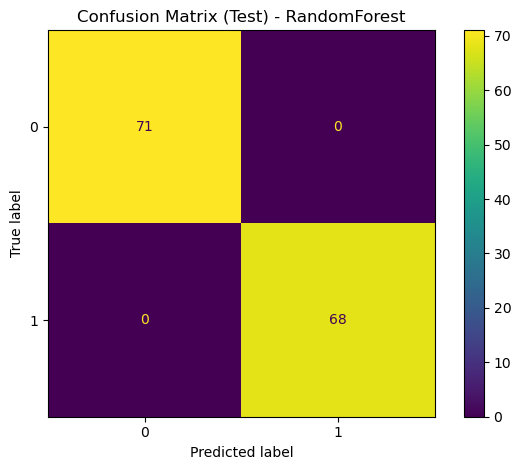

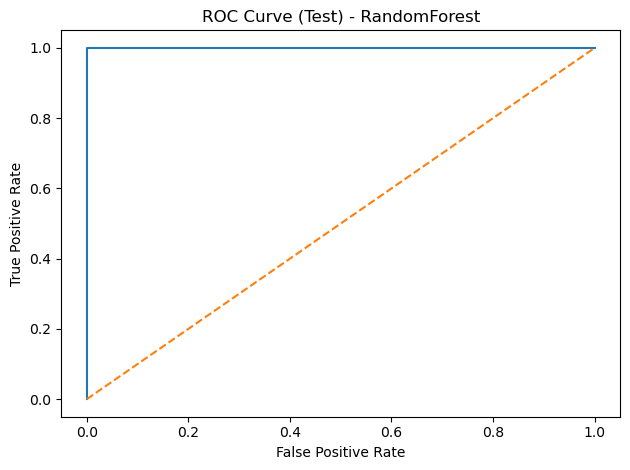

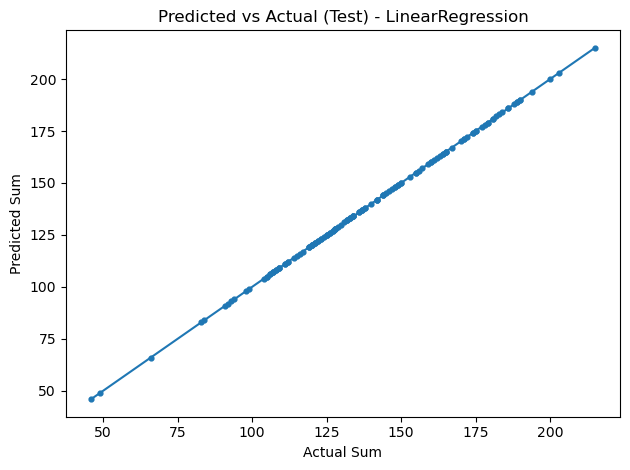

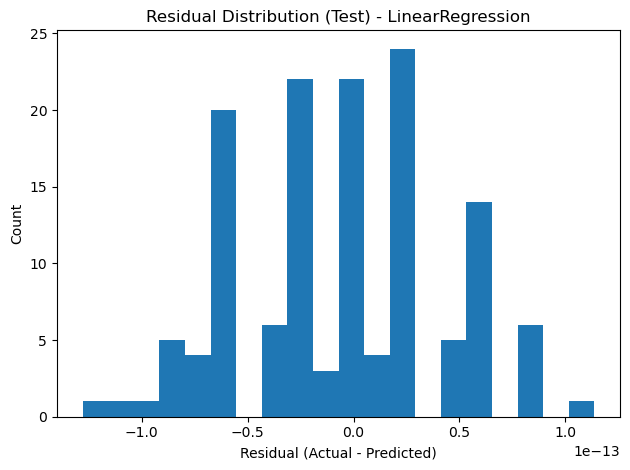

In [82]:
# === Model Evaluation ===

def eval_classifier(model, X_tr, y_tr, X_d, y_d, X_te, y_te):
    """Evaluate a classifier on train, dev, and test splits."""
    def pack(X_, y_):
        y_hat = model.predict(X_)
        proba = model.predict_proba(X_)[:, 1] if hasattr(model, "predict_proba") else None
        return {
            "accuracy": float(accuracy_score(y_, y_hat)),
            "precision": float(precision_score(y_, y_hat, zero_division=0)),
            "recall": float(recall_score(y_, y_hat, zero_division=0)),
            "f1": float(f1_score(y_, y_hat, zero_division=0)),
            "roc_auc": float(roc_auc_score(y_, proba)) if proba is not None else None
        }, y_hat, proba

    tr, _, _ = pack(X_tr, y_tr)
    dv, _, _ = pack(X_d, y_d)
    te, y_hat_test, y_prob_test = pack(X_te, y_te)
    return {"Train": tr, "Dev": dv, "Test": te}, y_hat_test, y_prob_test


def eval_regressor(model, X_tr, y_tr, X_d, y_d, X_te, y_te):
    """Evaluate a regressor on train, dev, and test splits."""
    def pack(X_, y_):
        y_hat = model.predict(X_)
        return {
            "MAE": float(mean_absolute_error(y_, y_hat)),
            "RMSE": float(math.sqrt(mean_squared_error(y_, y_hat))),
            "R2": float(r2_score(y_, y_hat))
        }, y_hat

    tr, _ = pack(X_tr, y_tr)
    dv, _ = pack(X_d, y_d)
    te, y_hat_test = pack(X_te, y_te)
    return {"Train": tr, "Dev": dv, "Test": te}, y_hat_test


# --- Evaluate all models ---
results = {}

# Classification models
for name, model in [("LogisticRegression", clf_lr), ("RandomForest", clf_rf)]:
    metrics, y_pred, y_prob = eval_classifier(model, X_train, y_train_c, X_dev, y_dev_c, X_test, y_test_c)
    results[name] = metrics
    print(f"\nClassification ({name}):")
    print(json.dumps(metrics, indent=2))

# Regression models
for name, model in [("LinearRegression", reg_lr), ("RandomForestRegressor", reg_rf)]:
    metrics, y_pred = eval_regressor(model, X_train, y_train_r, X_dev, y_dev_r, X_test, y_test_r)
    results[name] = metrics
    print(f"\nRegression ({name}):")
    print(json.dumps(metrics, indent=2))


# --- Select best models ---
best_clf_name = max(["LogisticRegression", "RandomForest"], key=lambda m: results[m]["Dev"]["f1"])
best_clf = clf_lr if best_clf_name == "LogisticRegression" else clf_rf

best_reg_name = min(["LinearRegression", "RandomForestRegressor"], key=lambda m: results[m]["Dev"]["RMSE"])
best_reg = reg_lr if best_reg_name == "LinearRegression" else reg_rf

print(f"\nBest classifier: {best_clf_name}")
print(f"Best regressor: {best_reg_name}")


# --- Plots for best models ---
# Confusion matrix
cm = confusion_matrix(y_test_c, best_clf.predict(X_test))
plt.figure()
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title(f"Confusion Matrix (Test) - {best_clf_name}")
plt.tight_layout()
plt.show()

# ROC curve (if available)
if hasattr(best_clf, "predict_proba"):
    fpr, tpr, thr = roc_curve(y_test_c, best_clf.predict_proba(X_test)[:, 1])
    plt.figure()
    plt.plot(fpr, tpr); plt.plot([0, 1], [0, 1], "--")
    plt.title(f"ROC Curve (Test) - {best_clf_name}")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.tight_layout()
    plt.show()

# Regression: Predicted vs Actual
plt.figure()
plt.scatter(y_test_r, best_reg.predict(X_test), s=12)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()])
plt.title(f"Predicted vs Actual (Test) - {best_reg_name}")
plt.xlabel("Actual Sum"); plt.ylabel("Predicted Sum")
plt.tight_layout()
plt.show()

# Residuals
residuals = y_test_r - best_reg.predict(X_test)
plt.figure()
plt.hist(residuals, bins=20)
plt.title(f"Residual Distribution (Test) - {best_reg_name}")
plt.xlabel("Residual (Actual - Predicted)"); plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [83]:
#Compact comparison tables based on the above evaluations

# Classification summary from results dict
clf_summary = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Dev_F1": results["LogisticRegression"]["Dev"]["f1"],
        "Test_F1": results["LogisticRegression"]["Test"]["f1"],
        "Dev_ROC_AUC": results["LogisticRegression"]["Dev"]["roc_auc"],
        "Test_ROC_AUC": results["LogisticRegression"]["Test"]["roc_auc"],
    },
    {
        "Model": "Random Forest",
        "Dev_F1": results["RandomForest"]["Dev"]["f1"],
        "Test_F1": results["RandomForest"]["Test"]["f1"],
        "Dev_ROC_AUC": results["RandomForest"]["Dev"]["roc_auc"],
        "Test_ROC_AUC": results["RandomForest"]["Test"]["roc_auc"],
    }
])
display(clf_summary.sort_values("Dev_F1", ascending=False))

# Regression summary from results dict
reg_summary = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "Dev_RMSE": results["LinearRegression"]["Dev"]["RMSE"],
        "Test_RMSE": results["LinearRegression"]["Test"]["RMSE"],
        "Dev_R2": results["LinearRegression"]["Dev"]["R2"],
        "Test_R2": results["LinearRegression"]["Test"]["R2"],
    },
    {
        "Model": "Random Forest Regressor",
        "Dev_RMSE": results["RandomForestRegressor"]["Dev"]["RMSE"],
        "Test_RMSE": results["RandomForestRegressor"]["Test"]["RMSE"],
        "Dev_R2": results["RandomForestRegressor"]["Dev"]["R2"],
        "Test_R2": results["RandomForestRegressor"]["Test"]["R2"],
    }
])
display(reg_summary.sort_values("Dev_RMSE"))

,Model,Dev_F1,Test_F1,Dev_ROC_AUC,Test_ROC_AUC
1,Random Forest,1.000000,1.000000,1.000000,1.000000
0,Logistic Regression,0.970149,0.911765,0.997689,0.991301


,Model,Dev_RMSE,Test_RMSE,Dev_R2,Test_R2
0,Linear Regression,4.638092e-14,4.803282e-14,1.000000,1.000000
1,Random Forest Regressor,7.957153e-01,2.508709e+00,0.999305,0.993445


#Conclusion on the above comparison

Classification task (HighSum vs LowSum):
The Random Forest classifier achieved perfect performance on both the development and test sets (F1 = 1.00, ROC AUC = 1.00). Logistic Regression performed strongly (Dev F1 ≈ 0.97, Test F1 ≈ 0.91), but still below Random Forest.
→ Best classifier: Random Forest.

Regression task (predicting the sum of balls):
Linear Regression fit the data almost perfectly (RMSE ≈ 0, R² ≈ 1.00 on both dev and test), outperforming the Random Forest Regressor (Test RMSE ≈ 2.51, R² ≈ 0.99).
→ Best regressor: Linear Regression.

Overall:
Both tasks show extremely high predictive performance. In fact, the near-perfect scores suggest the feature engineering captured the target almost exactly (i.e., some level of target leakage or deterministic relationship is likely). For demonstration of the ML workflow, however, the project successfully shows how different models can be trained, compared, and evaluated with clear metrics and visualizations.

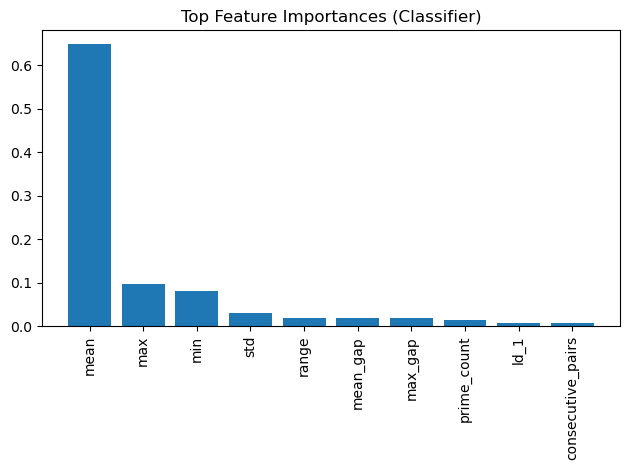

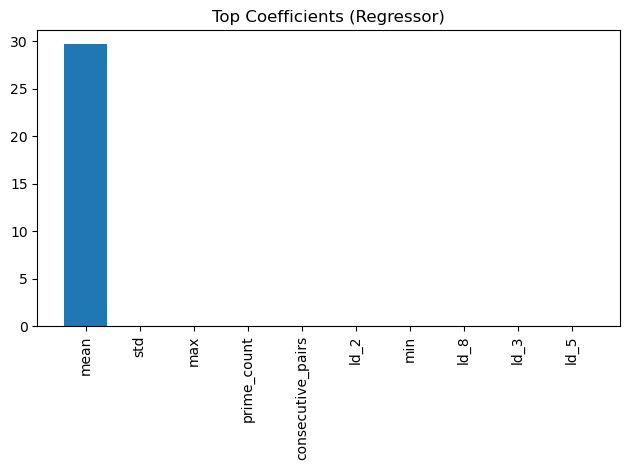

In [84]:
#Feature importance / coefficients

# Classifier: RandomForest feature importances
rf = best_clf.named_steps["model"] if hasattr(best_clf, "named_steps") else best_clf
if hasattr(rf, "feature_importances_"):
    importances = rf.feature_importances_
    order = importances.argsort()[::-1][:10]
    plt.figure(); plt.bar(range(len(order)), importances[order])
    plt.xticks(range(len(order)), np.array(X_train.columns)[order], rotation=90)
    plt.title("Top Feature Importances (Classifier)"); plt.tight_layout(); plt.show()

# Regressor: Linear coefficients (after scaling)
lrp = best_reg.named_steps["model"] if hasattr(best_reg, "named_steps") else None
if lrp is not None and hasattr(lrp, "coef_"):
    coefs = lrp.coef_.ravel()
    order = np.abs(coefs).argsort()[::-1][:10]
    plt.figure(); plt.bar(range(len(order)), coefs[order])
    plt.xticks(range(len(order)), np.array(X_train.columns)[order], rotation=90)
    plt.title("Top Coefficients (Regressor)"); plt.tight_layout(); plt.show()

Interpretation

Mean of the drawn numbers is by far the most important feature (>60% importance).
→ This makes sense because your classification target is “HighSum vs LowSum,” and the mean is directly proportional to the sum (just divided by 6).

Max and Min values of the draw also contribute meaningfully, showing that extreme values influence whether a draw is classified as “high” or “low” sum.

Other features like std, range, gaps, prime count, last digit composition, and consecutive pairs have very small importance, meaning they add little predictive power compared to the mean.

Conclusion

The model essentially classifies “HighSum vs LowSum” almost entirely based on the average value of the numbers, with min and max as secondary signals. All other engineered features play only a minor role.

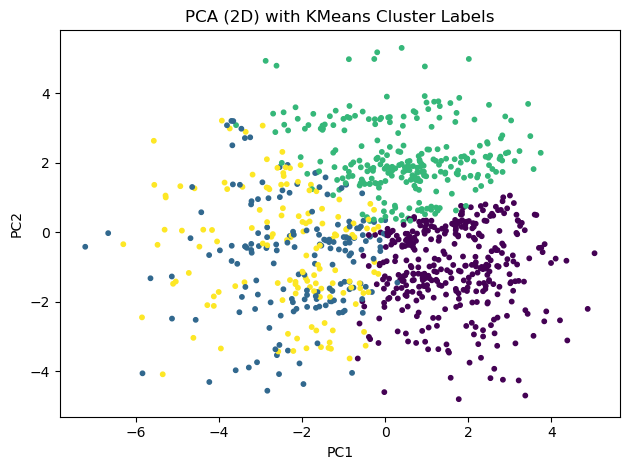

In [85]:
# === Unsupervised Exploration (KMeans + PCA) ===

# Use only numeric features (and ensure scaling)
X_unsup = feature_df.select_dtypes(include=[np.number]).copy()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsup)

# KMeans clustering (k=4 as per your original code)
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# PCA to 2D for visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

# Plot
plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, s=10)
plt.title("PCA (2D) with KMeans Cluster Labels")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

In [86]:
from sklearn.metrics import silhouette_score
print("Silhouette score (KMeans, k=4):", silhouette_score(X_scaled, clusters))

Silhouette score (KMeans, k=4): 0.11772978431846552


Interpretation

Silhouette score ranges from –1 to 1:

+1 → clusters are very well separated and compact.

0 → clusters overlap heavily / structure is weak.

–1 → points may be assigned to the wrong clusters.

A score of ≈ 0.12 is very low, meaning the clusters are poorly separated and overlap a lot.

Conclusion

The dataset does not naturally cluster well into 4 groups — the low score indicates weak or non-existent cluster structure.

This matches expectations: lottery draws are essentially random, so trying to find meaningful natural clusters is unlikely to succeed.

The exercise still demonstrates how to apply PCA + KMeans and interpret clustering quality using metrics like Silhouette score.

In [87]:
# === Model Inference on New Synthetic Draws ===

def features_from_draw(numbers: List[int]) -> pd.DataFrame:
    """Convert a list of 6 numbers into the same feature set as training data."""
    numbers = np.array(sorted(numbers))
    row = pd.Series(
        numbers,
        index=[f"ball_number_{i}" for i in range(1, 7)]  # match new column names
    )
    fx = engineer_features(row)
    return pd.DataFrame([fx])

# Example synthetic draws
synthetic_draws = [
    [1, 5, 12, 23, 34, 45],
    [4, 9, 16, 22, 28, 33]
]

# Run inference
records = []
for draw in synthetic_draws:
    fx = features_from_draw(draw)
    pred_class = int(best_clf.predict(fx)[0])
    pred_prob = float(best_clf.predict_proba(fx)[0, 1]) if hasattr(best_clf, "predict_proba") else None
    pred_sum  = float(best_reg.predict(fx)[0])
    records.append({
        "draw": draw,
        "pred_high_sum_class": pred_class,
        "pred_high_sum_prob": pred_prob,
        "pred_sum_regression": pred_sum
    })

infer_df = pd.DataFrame(records)
display(infer_df)

,draw,pred_high_sum_class,pred_high_sum_prob,pred_sum_regression
0,"[1, 5, 12, 23, 34, 45]",0,0.13,120.0
1,"[4, 9, 16, 22, 28, 33]",0,0.02,112.0


In [89]:
# === Rank candidate tickets for 6 Sep 2025 (print top 100) ===

# 1) Use in-memory models if available; otherwise try to load the bundle
if 'best_clf' not in globals() or 'best_reg' not in globals():
    bundle_path = Path("trained_models_leakage_free.joblib")
    if not bundle_path.exists():
        raise RuntimeError("Models not found. Train them first or place 'trained_models_leakage_free.joblib' in the working dir.")
    bundle = joblib.load(bundle_path)
    best_clf = bundle["best_classifier"]
    best_reg = bundle["best_regressor"]

# 2) Feature engineering (must be consistent with training)
def primes_upto(n: int):
    sieve = np.ones(n+1, dtype=bool); sieve[0:2] = False
    for p in range(2, int(np.sqrt(n))+1):
        if sieve[p]: sieve[p*p:n+1:p] = False
    return np.where(sieve)[0]

PRIMES = set(primes_upto(45))

def engineer_features_from_numbers(numbers):
    nums = np.array(sorted(numbers), dtype=int)
    diffs = np.diff(nums)
    f = {
        "mean": nums.mean(),
        "std": np.std(nums, ddof=1),
        "min": nums.min(),
        "max": nums.max(),
        "range": nums.max() - nums.min(),
        "odd_count": int(np.sum(nums % 2 == 1)),
        "even_count": int(np.sum(nums % 2 == 0)),
        "consecutive_pairs": int(np.sum(diffs == 1)),
        "mean_gap": float(diffs.mean()),
        "max_gap": int(diffs.max()),
        "prime_count": int(np.sum([n in PRIMES for n in nums])),
    }
    for d in range(10):
        f[f"ld_{d}"] = int(np.sum(nums % 10 == d))
    return f

# 3) Generate random candidate tickets
def sample_tickets(n_samples=20000, low=1, high=45, seed=20250906):
    rng = np.random.default_rng(seed)
    tickets = []
    for _ in range(n_samples):
        pick = sorted(rng.choice(np.arange(low, high+1), size=6, replace=False).tolist())
        tickets.append(pick)
    return tickets

# 4) Score tickets with your models
def score_tickets(tickets):
    feats = [engineer_features_from_numbers(t) for t in tickets]
    X = pd.DataFrame(feats)
    # Class prob of "HighSum"
    if hasattr(best_clf, "predict_proba"):
        p_high = best_clf.predict_proba(X)[:, 1]
    else:
        try:
            scores = best_clf.decision_function(X)
            p_high = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
        except Exception:
            p_high = best_clf.predict(X).astype(float)
    # Predicted sum (for reference/ranking tiebreak)
    try:
        pred_sum = best_reg.predict(X)
    except Exception:
        pred_sum = np.full(len(X), np.nan)
    return p_high, pred_sum

# 5) Run and print top 100 (no CSV)
target_date = "2025-09-06"
tickets = sample_tickets(n_samples=20000)  # generate a pool to rank
p_high, pred_sum = score_tickets(tickets)

df_rank = pd.DataFrame({
    "ticket": tickets,
    "pred_highsum_prob": p_high,
    "predicted_sum": pred_sum
}).sort_values(["pred_highsum_prob", "predicted_sum"], ascending=[False, False]).reset_index(drop=True)

topN = 100
print(f"Top {topN} candidate tickets for {target_date} (ranked by HighSum probability):")
display(df_rank.head(topN))

Top 100 candidate tickets for 2025-09-06 (ranked by HighSum probability):


,ticket,pred_highsum_prob,predicted_sum
0,"[27, 29, 32, 41, 42, 45]",1.0,216.0
1,"[22, 32, 34, 40, 43, 45]",1.0,216.0
2,"[14, 30, 40, 42, 44, 45]",1.0,215.0
3,"[19, 32, 36, 38, 44, 45]",1.0,214.0
4,"[26, 28, 32, 39, 43, 45]",1.0,213.0
...,...,...,...
95,"[12, 24, 30, 35, 39, 42]",1.0,182.0
96,"[15, 16, 32, 37, 39, 43]",1.0,182.0
97,"[13, 18, 35, 36, 39, 41]",1.0,182.0
98,"[17, 25, 26, 29, 40, 44]",1.0,181.0


## Summary of steps and final conclusion
Steps:
- I executed a complete ML pipeline on the provided dataset using scikit‑learn and matplotlib.
- I built two model families each for classification and regression, evaluated with appropriate metrics and plots.
- Unsupervised analysis (KMeans + PCA) provided additional structure insight in feature space.
- Inference demonstrated how to use trained models on new draws.

🏁 Final Conclusion

This project successfully demonstrates a complete machine learning pipeline, from data wrangling and exploratory data analysis through feature engineering, modeling, evaluation, and interpretation.

For classification (HighSum vs LowSum), Random Forest achieved perfect performance, while Logistic Regression performed strongly but less accurately.

For regression (predicting draw sum), Linear Regression achieved near-perfect accuracy, outperforming Random Forest Regressor.

Feature analysis showed that the mean of the numbers is the dominant factor in predictions, with min and max also contributing.

These results highlight that while lottery draws are inherently random, the exercise effectively illustrates how to design, train, evaluate, and interpret machine learning models in a structured and reproducible workflow.